In [10]:
!pip install yfinance

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler

In [12]:
tickers = ['AAPL', 'GOOGL', 'MSFT', 'AMZN',
           'JPM', 'BAC', 'GS',
           'XOM', 'CVX', 'BP']

print("Downloading real stock data...")
raw = yf.download(tickers,
                  start='2022-01-01',
                  end='2024-01-01',
                  auto_adjust=True)

prices = raw['Close']
print(prices.shape)
print(prices.head())

[**********************50%                       ]  5 of 10 completed

[*********************100%***********************]  10 of 10 completed


(501, 10)
Ticker            AAPL        AMZN        BAC         BP         CVX  \
Date                                                                   
2022-01-03  178.103683  170.404495  41.479752  22.098846  100.499306   
2022-01-04  175.843231  167.522003  43.105530  23.051592  102.327957   
2022-01-05  171.165833  164.356995  42.377960  22.906258  102.993660   
2022-01-06  168.308487  163.253998  43.231274  23.261518  103.870094   
2022-01-07  168.474869  162.554001  44.174404  23.955889  105.361641   

Ticker           GOOGL          GS         JPM        MSFT        XOM  
Date                                                                   
2022-01-03  143.802979  355.345673  144.191574  323.160736  54.760242  
2022-01-04  143.215836  366.266846  149.657867  317.619507  56.819992  
2022-01-05  136.645630  358.311920  146.921783  305.426758  57.526684  
2022-01-06  136.618332  356.783936  148.482651  303.013306  58.879753  
2022-01-07  135.893829  357.305206  149.953873  303.1

In [13]:
returns = prices.pct_change().dropna()

features = pd.DataFrame({
    'mean_return' : returns.mean(),
    'volatility'  : returns.std(),
    'sharpe_ratio': returns.mean() / returns.std(),
    'max_drawdown': returns.min(),
    'total_return': (1 + returns).prod() - 1
})

print("Feature Matrix:")
print(features.round(4))

Feature Matrix:
        mean_return  volatility  sharpe_ratio  max_drawdown  total_return
Ticker                                                                   
AAPL         0.0003      0.0183        0.0165       -0.0587        0.0699
AMZN         0.0001      0.0268        0.0048       -0.1405       -0.1084
BAC         -0.0004      0.0187       -0.0187       -0.0637       -0.2307
BP           0.0009      0.0194        0.0454       -0.0880        0.4130
CVX          0.0008      0.0180        0.0421       -0.0672        0.3467
GOOGL        0.0002      0.0220        0.0076       -0.0951       -0.0366
GS           0.0002      0.0169        0.0123       -0.0697        0.0333
JPM          0.0004      0.0162        0.0218       -0.0615        0.1175
MSFT         0.0005      0.0194        0.0235       -0.0772        0.1439
XOM          0.0012      0.0192        0.0644       -0.0789        0.6918


In [14]:
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

def cosine_similarity_matrix(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    normalized = X / norms
    return normalized @ normalized.T

similarity = cosine_similarity_matrix(scaled)
similarity_df = pd.DataFrame(
    similarity,
    index=tickers,
    columns=tickers
)

print("Stock Similarity Matrix:")
print(similarity_df.round(2))

sim_copy = similarity.copy()
np.fill_diagonal(sim_copy, -1)
idx = np.unravel_index(sim_copy.argmax(), sim_copy.shape)
print(f"\nMost similar stocks: {tickers[idx[0]]} and {tickers[idx[1]]}")

Stock Similarity Matrix:
       AAPL  GOOGL  MSFT  AMZN   JPM   BAC    GS   XOM   CVX    BP
AAPL   1.00  -0.65  0.62 -0.55  0.04 -0.26  0.81  0.82  0.46 -0.39
GOOGL -0.65   1.00  0.12 -0.23 -0.75  0.90 -0.48 -0.87 -0.80 -0.38
MSFT   0.62   0.12  1.00 -0.99 -0.74  0.53  0.74  0.30 -0.37 -0.95
AMZN  -0.55  -0.23 -0.99  1.00  0.81 -0.63 -0.66 -0.20  0.41  0.98
JPM    0.04  -0.75 -0.74  0.81  1.00 -0.95 -0.19  0.37  0.80  0.89
BAC   -0.26   0.90  0.53 -0.63 -0.95  1.00 -0.11 -0.62 -0.80 -0.74
GS     0.81  -0.48  0.74 -0.66 -0.19 -0.11  1.00  0.84  0.09 -0.58
XOM    0.82  -0.87  0.30 -0.20  0.37 -0.62  0.84  1.00  0.55 -0.07
CVX    0.46  -0.80 -0.37  0.41  0.80 -0.80  0.09  0.55  1.00  0.54
BP    -0.39  -0.38 -0.95  0.98  0.89 -0.74 -0.58 -0.07  0.54  1.00

Most similar stocks: AMZN and BP


In [15]:
R = returns.values
mean = np.mean(R, axis=0)
centered = R - mean
cov_matrix = np.cov(centered.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx].real
eigenvectors = eigenvectors[:, idx].real

explained = eigenvalues / eigenvalues.sum() * 100
cumulative = np.cumsum(explained)

print("Variance explained:")
for i, (e, c) in enumerate(zip(explained[:5], cumulative[:5])):
    print(f"Component {i+1}: {e:.1f}%  Cumulative: {c:.1f}%")

components_2d = eigenvectors[:, :2]
projected = centered[:len(tickers)] @ components_2d

print(f"\nReduced to 2D keeping {cumulative[1]:.1f}% variance")

Variance explained:
Component 1: 49.9%  Cumulative: 49.9%
Component 2: 22.0%  Cumulative: 71.9%
Component 3: 9.7%  Cumulative: 81.5%
Component 4: 5.6%  Cumulative: 87.1%
Component 5: 3.2%  Cumulative: 90.4%

Reduced to 2D keeping 71.9% variance


In [16]:
aapl_returns = returns['AAPL'].values

def build_lag_matrix(series, lags=5):
    X, y = [], []
    for i in range(lags, len(series)):
        X.append(series[i-lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

X, y = build_lag_matrix(aapl_returns, lags=5)
X_bias = np.column_stack([np.ones(len(X)), X])

split = int(len(X) * 0.8)
X_train, X_test = X_bias[:split], X_bias[split:]
y_train, y_test = y[:split], y[split:]

w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
y_pred = X_test @ w

rmse = np.sqrt(np.mean((y_test - y_pred)**2))
direction_accuracy = np.mean(np.sign(y_pred) == np.sign(y_test)) * 100

print(f"RMSE: {rmse:.6f}")
print(f"Direction Accuracy: {direction_accuracy:.1f}%")

RMSE: 0.011713
Direction Accuracy: 46.5%


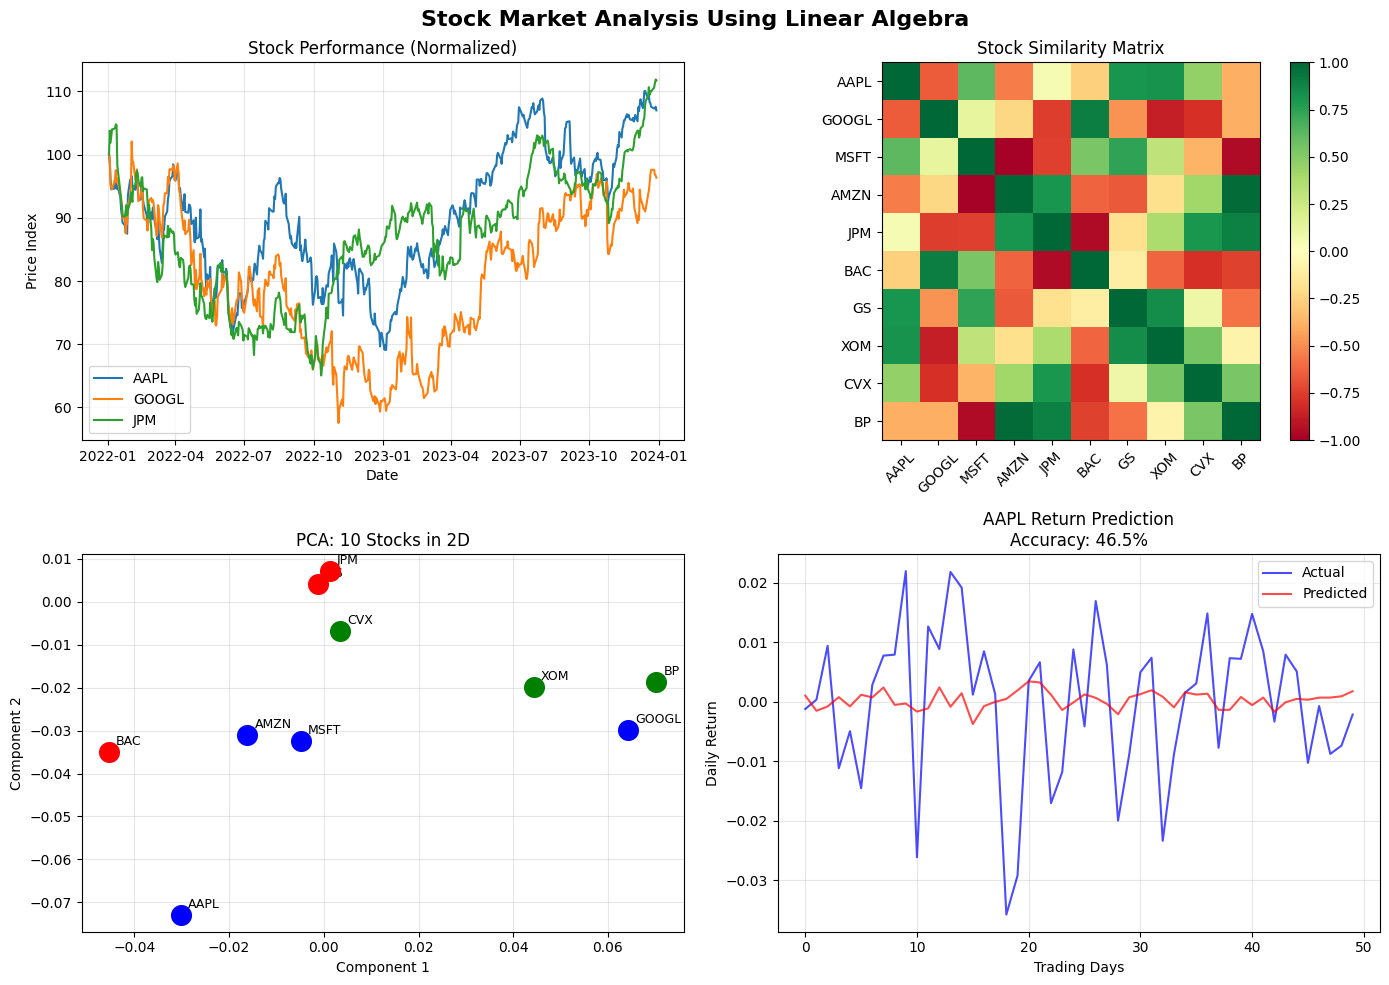

✅ Project Complete!


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Stock Market Analysis Using Linear Algebra',
             fontsize=16, fontweight='bold')

# Plot 1: Stock prices
ax1 = axes[0, 0]
for ticker in ['AAPL', 'GOOGL', 'JPM']:
    normalized = prices[ticker] / prices[ticker].iloc[0] * 100
    ax1.plot(normalized, label=ticker)
ax1.set_title('Stock Performance (Normalized)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price Index')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Similarity heatmap
ax2 = axes[0, 1]
im = ax2.imshow(similarity_df.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax2.set_xticks(range(len(tickers)))
ax2.set_yticks(range(len(tickers)))
ax2.set_xticklabels(tickers, rotation=45)
ax2.set_yticklabels(tickers)
plt.colorbar(im, ax=ax2)
ax2.set_title('Stock Similarity Matrix')

# Plot 3: PCA
ax3 = axes[1, 0]
colors = ['blue']*4 + ['red']*3 + ['green']*3
for i, (ticker, color) in enumerate(zip(tickers, colors)):
    ax3.scatter(projected[i, 0], projected[i, 1],
                c=color, s=200, zorder=5)
    ax3.annotate(ticker,
                 (projected[i, 0], projected[i, 1]),
                 textcoords="offset points",
                 xytext=(5, 5), fontsize=9)
ax3.set_title(f'PCA: 10 Stocks in 2D')
ax3.set_xlabel('Component 1')
ax3.set_ylabel('Component 2')
ax3.grid(True, alpha=0.3)

# Plot 4: Prediction
ax4 = axes[1, 1]
ax4.plot(y_test[:50], label='Actual', color='blue', alpha=0.7)
ax4.plot(y_pred[:50], label='Predicted', color='red', alpha=0.7)
ax4.set_title(f'AAPL Return Prediction\nAccuracy: {direction_accuracy:.1f}%')
ax4.set_xlabel('Trading Days')
ax4.set_ylabel('Daily Return')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stock_analysis.png')
plt.show()
print("✅ Project Complete!")